# Dependencies

In [10]:
!pip install yfinance pandas numpy matplotlib

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timezone
import scipy.stats as si

# YZ VS RV Plot

/tmp/ipython-input-1740914230.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start='2022-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


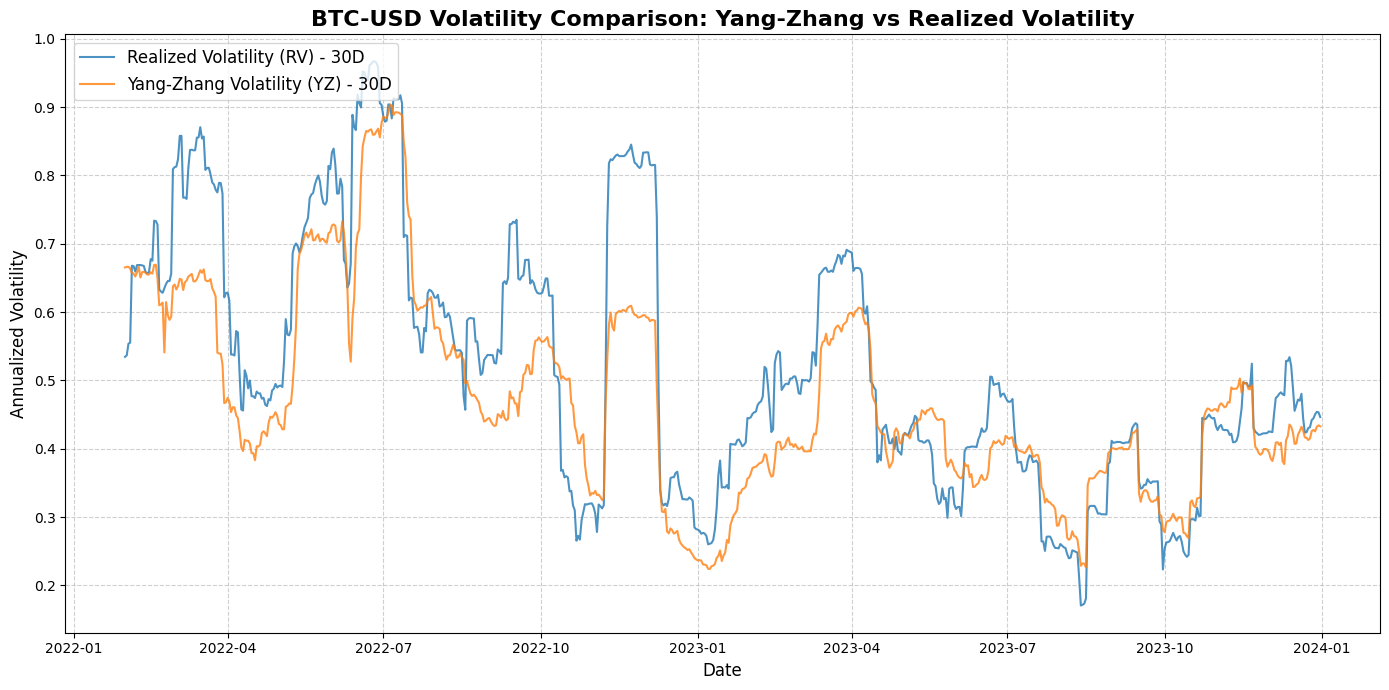

In [12]:
# 1. Fetch historical BTC data
symbol = 'BTC-USD'
# Using 2 years of data for a good visualization
df = yf.download(symbol, start='2022-01-01', end='2024-01-01')

# Flatten the multi-index columns if yfinance returns them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Parameters
window = 30           # 30-day rolling window for volatility
trading_days = 365    # Crypto trades 24/7, so we annualize with 365

# ---------------------------------------------------------
# 2. Realized Volatility (RV) Calculation (Close-to-Close)
# ---------------------------------------------------------
# Daily log returns
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))

# Annualized rolling standard deviation (Sample standard deviation ddof=1)
df['RV'] = df['Log_Ret'].rolling(window=window).std(ddof=1) * np.sqrt(trading_days)

# ---------------------------------------------------------
# 3. Yang-Zhang (YZ) Volatility Calculation
# ---------------------------------------------------------
# Log prices
log_ho = np.log(df['High'] / df['Open'])
log_lo = np.log(df['Low'] / df['Open'])
log_co = np.log(df['Close'] / df['Open'])

# Overnight returns (Previous Close to Current Open)
log_oc = np.log(df['Open'] / df['Close'].shift(1))

# Rogers-Satchell daily variance
rs_var = log_ho * (log_ho - log_co) + log_lo * (log_lo - log_co)

# Rolling sample variances (using ddof=1 for sample variance)
var_o = log_oc.rolling(window=window).var(ddof=1)
var_c = log_co.rolling(window=window).var(ddof=1)
var_rs = rs_var.rolling(window=window).mean()

# Yang-Zhang k-parameter
k = 0.34 / (1.34 + (window + 1) / (window - 1))

# Yang-Zhang variance and annualized volatility
yz_var = var_o + k * var_c + (1 - k) * var_rs
df['YZ'] = np.sqrt(yz_var) * np.sqrt(trading_days)

# Drop missing values resulting from the rolling window
df.dropna(inplace=True)

# ---------------------------------------------------------
# 4. Plotting
# ---------------------------------------------------------
plt.figure(figsize=(14, 7))

# Plot both Volatilities
plt.plot(df.index, df['RV'], label=f'Realized Volatility (RV) - {window}D', color='#1f77b4', linewidth=1.5, alpha=0.8)
plt.plot(df.index, df['YZ'], label=f'Yang-Zhang Volatility (YZ) - {window}D', color='#ff7f0e', linewidth=1.5, alpha=0.8)

# Formatting the plot
plt.title(f'{symbol} Volatility Comparison: Yang-Zhang vs Realized Volatility', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Annualized Volatility', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# YZ VS RV Correlation and Difference

/tmp/ipython-input-2661345064.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start='2022-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


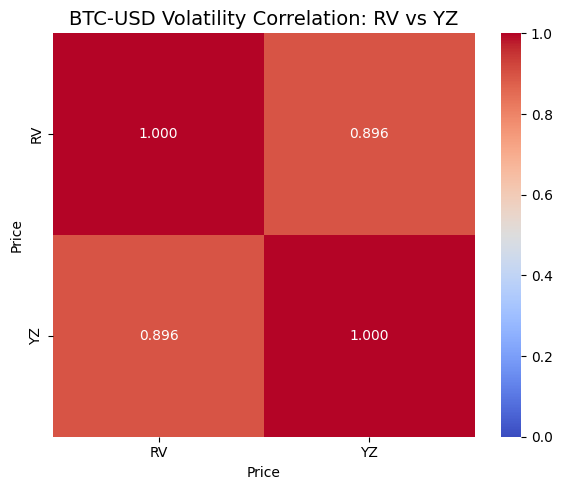


--- VOLATILITY DIFFERENCE ANALYSIS ---
Correlation: 0.8959

--- Absolute Difference Interval (Annualized Volatility Points) ---
Average Absolute Difference: -0.0473
95% Confidence Interval for Difference: [-0.2361, 0.1218]

--- Relative Difference (% Larger/Smaller) ---
Average Relative Difference: -6.19%
Median Relative Difference: -8.64%
95% Confidence Interval (Relative): [-30.45%, 35.20%]


In [13]:
# 1. Fetch historical BTC data
symbol = 'BTC-USD'
df = yf.download(symbol, start='2022-01-01', end='2024-01-01')

# Flatten multi-index columns if yfinance returns them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

window = 30
trading_days = 365

# 2. Realized Volatility (RV) - Close-to-Close
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df['RV'] = df['Log_Ret'].rolling(window=window).std(ddof=1) * np.sqrt(trading_days)

# 3. Yang-Zhang Volatility (YZ)
log_ho = np.log(df['High'] / df['Open'])
log_lo = np.log(df['Low'] / df['Open'])
log_co = np.log(df['Close'] / df['Open'])
log_oc = np.log(df['Open'] / df['Close'].shift(1))

rs_var = log_ho * (log_ho - log_co) + log_lo * (log_lo - log_co)
var_o = log_oc.rolling(window=window).var(ddof=1)
var_c = log_co.rolling(window=window).var(ddof=1)
var_rs = rs_var.rolling(window=window).mean()

k = 0.34 / (1.34 + (window + 1) / (window - 1))
yz_var = var_o + k * var_c + (1 - k) * var_rs
df['YZ'] = np.sqrt(yz_var) * np.sqrt(trading_days)

df.dropna(inplace=True)

# ---------------------------------------------------------
# 4. Correlation Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(6, 5))
corr_matrix = df[['RV', 'YZ']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=0, vmax=1)
plt.title(f'{symbol} Volatility Correlation: RV vs YZ', fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Difference Intervals & Relative Terms Calculation
# ---------------------------------------------------------
# Absolute Difference
df['Abs_Diff'] = df['YZ'] - df['RV']

# Relative Difference in Percentage: How much bigger is YZ compared to RV?
df['Rel_Diff_Pct'] = ((df['YZ'] - df['RV']) / df['RV']) * 100

print("\n--- VOLATILITY DIFFERENCE ANALYSIS ---")
print(f"Correlation: {corr_matrix.loc['RV', 'YZ']:.4f}")

print("\n--- Absolute Difference Interval (Annualized Volatility Points) ---")
print(f"Average Absolute Difference: {df['Abs_Diff'].mean():.4f}")
print(f"95% Confidence Interval for Difference: [{df['Abs_Diff'].quantile(0.025):.4f}, {df['Abs_Diff'].quantile(0.975):.4f}]")

print("\n--- Relative Difference (% Larger/Smaller) ---")
print(f"Average Relative Difference: {df['Rel_Diff_Pct'].mean():.2f}%")
print(f"Median Relative Difference: {df['Rel_Diff_Pct'].median():.2f}%")
print(f"95% Confidence Interval (Relative): [{df['Rel_Diff_Pct'].quantile(0.025):.2f}%, {df['Rel_Diff_Pct'].quantile(0.975):.2f}%]")

# BS Option Pricing - YZ vs RV

Fetching Spot Data from Kraken...
Kraken Spot: $67,531.60 | RV: 79.5% | YZ: 68.9%
Fetching Options from Deribit...
Plotting curve for Target Expiry: 27MAR26


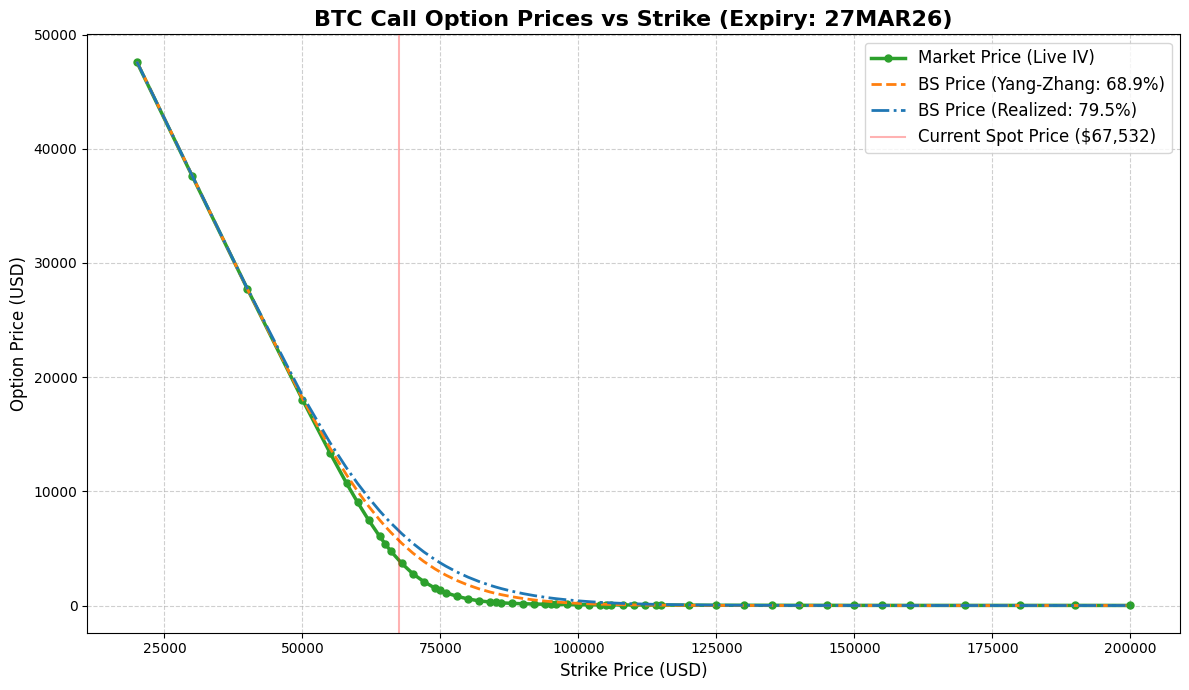

In [17]:
# ==========================================
# 1. Fetch Spot Data & Calc Volatilities
# ==========================================
print("Fetching Spot Data from Kraken...")
kraken_url = "https://api.kraken.com/0/public/OHLC?pair=XBTUSD&interval=1440"
k_res = requests.get(kraken_url).json()

k_data = k_res['result']['XXBTZUSD']
df_spot = pd.DataFrame(k_data, columns=['Time', 'Open', 'High', 'Low', 'Close', 'VWAP', 'Volume', 'Count'])
df_spot = df_spot[['Time', 'Open', 'High', 'Low', 'Close']].astype(float).tail(31).reset_index(drop=True)

# Calculate Volatilities
window = 30
trading_days = 365

df_spot['Log_Ret'] = np.log(df_spot['Close'] / df_spot['Close'].shift(1))
current_rv = (df_spot['Log_Ret'].rolling(window=window).std(ddof=1) * np.sqrt(trading_days)).iloc[-1]

log_ho = np.log(df_spot['High'] / df_spot['Open'])
log_lo = np.log(df_spot['Low'] / df_spot['Open'])
log_co = np.log(df_spot['Close'] / df_spot['Open'])
log_oc = np.log(df_spot['Open'] / df_spot['Close'].shift(1))
rs_var = log_ho * (log_ho - log_co) + log_lo * (log_lo - log_co)

var_o = log_oc.rolling(window=window).var(ddof=1)
var_c = log_co.rolling(window=window).var(ddof=1)
var_rs = rs_var.rolling(window=window).mean()
k_yz = 0.34 / (1.34 + (window + 1) / (window - 1))

current_yz = (np.sqrt(var_o + k_yz * var_c + (1 - k_yz) * var_rs) * np.sqrt(trading_days)).iloc[-1]
latest_spot = df_spot['Close'].iloc[-1]

print(f"Kraken Spot: ${latest_spot:,.2f} | RV: {current_rv*100:.1f}% | YZ: {current_yz*100:.1f}%")

# ==========================================
# 2. Black-Scholes Function
# ==========================================
def bs_price(S, K, T, r, sigma, option_type='C'):
    if T <= 0: return max(S - K, 0) if option_type == 'C' else max(K - S, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'C':
        return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)

# ==========================================
# 3. Fetch Deribit Options (Filter 1 Expiry)
# ==========================================
print("Fetching Options from Deribit...")
deribit_url = "https://www.deribit.com/api/v2/public/get_book_summary_by_currency?currency=BTC&kind=option"
d_res = requests.get(deribit_url).json()
btc_opts = d_res['result']

# Find all Call options, and extract the expiries
expiries = [opt['instrument_name'].split('-')[1] for opt in btc_opts if opt['instrument_name'].endswith('-C')]
# Pick the expiry date that has the most strikes listed to get a smooth curve
target_expiry = max(set(expiries), key=expiries.count)
print(f"Plotting curve for Target Expiry: {target_expiry}")

now = datetime.now(timezone.utc)
expiry_date = datetime.strptime(target_expiry, "%d%b%y").replace(hour=8, tzinfo=timezone.utc)
T = (expiry_date - now).total_seconds() / (24 * 3600 * 365.0)
r = 0.05

results = []
for opt in btc_opts:
    parts = opt['instrument_name'].split('-')
    # Filter for our target expiry and Call options
    if len(parts) != 4 or parts[1] != target_expiry or parts[3] != 'C':
        continue

    strike = float(parts[2])
    mark_price_btc = opt.get('mark_price')
    if mark_price_btc is None: continue

    underlying_price = opt.get('estimated_delivery_price', latest_spot)
    market_price_usd = mark_price_btc * underlying_price

    if market_price_usd < 5: continue # Ignore 0-value extreme OTM options

    rv_price = bs_price(underlying_price, strike, T, r, current_rv, 'C')
    yz_price = bs_price(underlying_price, strike, T, r, current_yz, 'C')

    results.append({
        'Strike': strike,
        'Market Price': market_price_usd,
        'BS (RV)': rv_price,
        'BS (YZ)': yz_price
    })

# Convert to DataFrame and sort by Strike price (so the line plots left-to-right correctly)
df_results = pd.DataFrame(results).sort_values('Strike')

# ==========================================
# 4. Plotting the Curves
# ==========================================
plt.figure(figsize=(12, 7))

# Plot lines
plt.plot(df_results['Strike'], df_results['Market Price'], label='Market Price (Live IV)', color='#2ca02c', linewidth=2.5, marker='o', markersize=5)
plt.plot(df_results['Strike'], df_results['BS (YZ)'], label=f'BS Price (Yang-Zhang: {current_yz*100:.1f}%)', color='#ff7f0e', linewidth=2, linestyle='--')
plt.plot(df_results['Strike'], df_results['BS (RV)'], label=f'BS Price (Realized: {current_rv*100:.1f}%)', color='#1f77b4', linewidth=2, linestyle='-.')

# Formatting
plt.axvline(x=latest_spot, color='red', linestyle='-', alpha=0.3, label=f'Current Spot Price (${latest_spot:,.0f})')
plt.title(f'BTC Call Option Prices vs Strike (Expiry: {target_expiry})', fontsize=16, fontweight='bold')
plt.xlabel('Strike Price (USD)', fontsize=12)
plt.ylabel('Option Price (USD)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [18]:
# ==========================================
# 1. Fetch Spot Data & Calc Volatilities (Kraken)
# ==========================================
print("Fetching underlying spot data...")
kraken_url = "https://api.kraken.com/0/public/OHLC?pair=XBTUSD&interval=1440"
k_res = requests.get(kraken_url).json()

k_data = k_res['result']['XXBTZUSD']
df_spot = pd.DataFrame(k_data, columns=['Time', 'Open', 'High', 'Low', 'Close', 'VWAP', 'Volume', 'Count'])
df_spot = df_spot[['Time', 'Open', 'High', 'Low', 'Close']].astype(float).tail(31).reset_index(drop=True)

window = 30
trading_days = 365

# RV Calc
df_spot['Log_Ret'] = np.log(df_spot['Close'] / df_spot['Close'].shift(1))
current_rv = (df_spot['Log_Ret'].rolling(window=window).std(ddof=1) * np.sqrt(trading_days)).iloc[-1]

# YZ Calc
log_ho = np.log(df_spot['High'] / df_spot['Open'])
log_lo = np.log(df_spot['Low'] / df_spot['Open'])
log_co = np.log(df_spot['Close'] / df_spot['Open'])
log_oc = np.log(df_spot['Open'] / df_spot['Close'].shift(1))
rs_var = log_ho * (log_ho - log_co) + log_lo * (log_lo - log_co)

var_o = log_oc.rolling(window=window).var(ddof=1)
var_c = log_co.rolling(window=window).var(ddof=1)
var_rs = rs_var.rolling(window=window).mean()
k_yz = 0.34 / (1.34 + (window + 1) / (window - 1))
current_yz = (np.sqrt(var_o + k_yz * var_c + (1 - k_yz) * var_rs) * np.sqrt(trading_days)).iloc[-1]

latest_spot = df_spot['Close'].iloc[-1]

# ==========================================
# 2. Fetch Options & Compare (Deribit)
# ==========================================
def bs_price(S, K, T, r, sigma, option_type='C'):
    if T <= 0: return max(S - K, 0) if option_type == 'C' else max(K - S, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'C': return S * si.norm.cdf(d1) - K * np.exp(-r * T) * si.norm.cdf(d2)
    else: return K * np.exp(-r * T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)

print("Fetching active options...")
deribit_url = "https://www.deribit.com/api/v2/public/get_book_summary_by_currency?currency=BTC&kind=option"
d_res = requests.get(deribit_url).json()
btc_opts = d_res['result']

now = datetime.now(timezone.utc)
r = 0.05
results = []

for opt in btc_opts:
    parts = opt.get('instrument_name', '').split('-')
    if len(parts) != 4 or parts[3] != 'C': continue # Only look at Calls for fair comparison

    strike = float(parts[2])
    expiry_date = datetime.strptime(parts[1], "%d%b%y").replace(hour=8, tzinfo=timezone.utc)
    T = (expiry_date - now).total_seconds() / (24 * 3600 * 365.0)

    if not (7 < T * 365 < 90): continue # Filter out extreme short/long dated options

    mark_price_btc = opt.get('mark_price')
    if mark_price_btc is None: continue

    underlying_price = opt.get('estimated_delivery_price', latest_spot)
    market_price_usd = mark_price_btc * underlying_price

    if market_price_usd < 10: continue # Filter out illiquid junk options

    # Generate calculated prices
    rv_price = bs_price(underlying_price, strike, T, r, current_rv, 'C')
    yz_price = bs_price(underlying_price, strike, T, r, current_yz, 'C')

    results.append({
        'Market Price': market_price_usd,
        'BS (RV)': rv_price,
        'BS (YZ)': yz_price
    })

# ==========================================
# 3. Mathematical Error Analysis
# ==========================================
df = pd.DataFrame(results)

if df.empty:
    print("No options passed the filters to analyze.")
else:
    # 1. Absolute Dollar Errors
    df['RV_Abs_Err'] = np.abs(df['BS (RV)'] - df['Market Price'])
    df['YZ_Abs_Err'] = np.abs(df['BS (YZ)'] - df['Market Price'])

    # 2. Relative Percentage Errors
    df['RV_Pct_Err'] = (df['RV_Abs_Err'] / df['Market Price']) * 100
    df['YZ_Pct_Err'] = (df['YZ_Abs_Err'] / df['Market Price']) * 100

    print("\n===========================================")
    print("      VOLATILITY PRICING ERROR REPORT        ")
    print("===========================================")
    print(f"Total Options Analyzed: {len(df)}")

    print("\n--- Absolute Dollar Error (Per Option) ---")
    print("How far off was the estimated price in dollars?")
    print(f"Mean Error (RV): ${df['RV_Abs_Err'].mean():.2f}")
    print(f"Mean Error (YZ): ${df['YZ_Abs_Err'].mean():.2f}")

    print("\n--- Median Percentage Error ---")
    print("How wrong was the estimate as a percentage?")
    print(f"Median Error (RV): {df['RV_Pct_Err'].median():.2f}% off from market")
    print(f"Median Error (YZ): {df['YZ_Pct_Err'].median():.2f}% off from market")
    print("===========================================")

    # Conclusion logic
    if df['YZ_Pct_Err'].median() < df['RV_Pct_Err'].median():
        improvement = df['RV_Pct_Err'].median() - df['YZ_Pct_Err'].median()
        print(f"\nCONCLUSION: Yang-Zhang (YZ) was significantly more accurate.")
        print(f"It reduced the median pricing error by {improvement:.2f} percentage points compared to Standard RV!")
    else:
        print("\nCONCLUSION: Realized Volatility (RV) was more accurate today.")

Fetching underlying spot data...
Fetching active options...

      VOLATILITY PRICING ERROR REPORT        
Total Options Analyzed: 128

--- Absolute Dollar Error (Per Option) ---
How far off was the estimated price in dollars?
Mean Error (RV): $1545.31
Mean Error (YZ): $970.90

--- Median Percentage Error ---
How wrong was the estimate as a percentage?
Median Error (RV): 106.90% off from market
Median Error (YZ): 69.36% off from market

CONCLUSION: Yang-Zhang (YZ) was significantly more accurate.
It reduced the median pricing error by 37.55 percentage points compared to Standard RV!
